# Working with synthetic data

In [7]:
###### defining the ideal transmission amplitude as function of frequency w #######
# from equation (A1) in https://arxiv.org/pdf/2307.07765

from numpy import cos, exp, abs

def s_out_in(
    A, # amplitude
    k, # tilt in the spectrum
    w_0, # center of the spectrum
    phi, # phase rotation induced by capacitive coupling to other lines
    k_p, # external coupling rate of the Purcell filter
    w_p, # Purcell filter frequency
    w_res_0, # resonator frequency at state 0
    w_res_1, # frequency at state 1
    J, # the transmon resonator coupling rate
    #a,
    ):

    return lambda w: (A + k*(w-w_0)/w_0)*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_0)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_0)))), lambda w: (A + k*(w-w_0)/w_0)*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_1)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_1))))

### using data with no noise, no tilt, no center dislocation, and no phase rotation induced by couplings

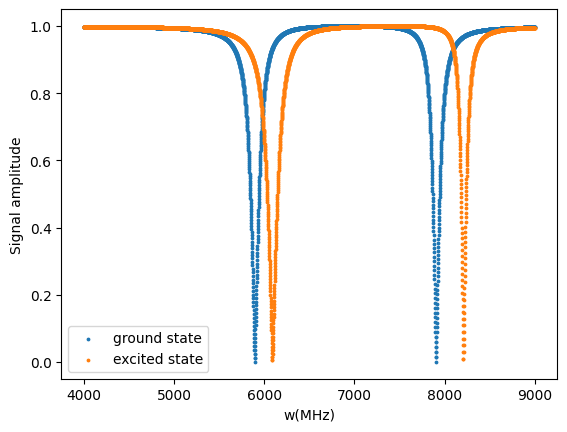

In [2]:
import matplotlib.pyplot as plt
import numpy as np

test_0,test_1 = s_out_in(A=1, k=0,w_0=0, phi=0,k_p=3e2,w_p=6.8e3,w_res_0=7e3,w_res_1=7.5e3,J=1000)

x = (1e3)*np.linspace(4,9,5001)
data_0 = test_0(x)
data_1 = test_1(x)
plt.scatter(x,data_0, s=3, label="ground state")
plt.scatter(x,data_1, s=3, label="excited state")
plt.xlabel("w(MHz)")
plt.ylabel("Signal amplitude")
plt.legend()

In [56]:
# fitting a curve to the data
from scipy.optimize import curve_fit

# the fitting curve
def s_out_in_for_fitting_0(w,A,k,w_0,phi,k_p,w_p,w_res_0,J):
    return (A + k*(w-w_0))*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_0)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_0))))

# Initial guesses for parameters
initial_guess = [1.1,0,0,0,3.1e2,6.8e3,7e3,1005]

popt, pcov = curve_fit(s_out_in_for_fitting_0, x, data_0, p0=initial_guess)

/tmp/ipykernel_756969/2024393335.py:11: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(s_out_in_for_fitting_0, x, data_0, p0=initial_guess)


In [119]:
y_values = [s_out_in_for_fitting_0(w,popt[0],popt[1],popt[2],popt[3],popt[4],popt[5],popt[6],popt[7]) for w in x]

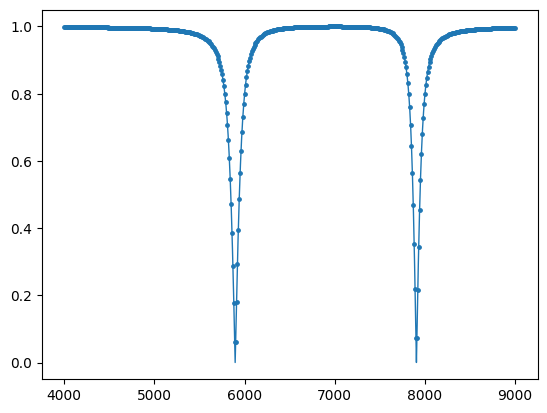

In [129]:
plt.scatter(x[::10],data_0[::10],s=6)
plt.plot(x,y_values, lw=1)

In [25]:
# using least square
from scipy.optimize import least_squares

def residuals(params, w, y):
    A,k,w_0,phi,k_p,w_p,w_res_0,J = params
    return (A + k*(w-w_0))*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_0)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_0)))) - y

result = least_squares(residuals, x0=[1.1,0,0,0,3.1e2,6.8e3,7e3,1005], args=(x, data_0))


NameError: name 'x' is not defined

### using data with error bars

In [33]:
# using least square
from scipy.optimize import least_squares

def residuals(params, w, y, y_err):
    A,k,w_0,phi,k_p,w_p,w_res_0,J = params
    return ((A + k*(w-w_0))*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_0)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_0)))) - y)/y_err

y_err = [0.0005]*len(data_0)

result = least_squares(residuals, x0=[1.1,0,0,0,3.1e2,6.8e3,7e3,1005], args=(x, data_0, y_err))

In [34]:
dof = len(data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(7.570207566994054e-11)

### using data with error bars and noise

In [3]:
from numpy.random import random

noise = (random(len(data_0))-0.5)/100
noise[:20]

array([ 1.41438094e-03,  4.59121286e-03,  1.21138890e-04,  2.06080427e-03,
        4.63275574e-04, -4.64089965e-04,  3.97625772e-03,  7.38803380e-04,
        3.29353913e-03,  4.34481403e-03,  2.81988072e-03,  4.05135382e-03,
       -3.68330481e-03, -4.23701816e-05,  1.88985660e-03, -1.50178252e-03,
       -2.92973824e-03, -4.20730659e-03,  6.00002470e-04, -4.83530313e-03])

In [4]:
noise_data_0 = data_0 + noise
data_error_bars = [0.1]*len(data_0)

# result = least_squares(residuals, x0=[1.1,0,0,0,3.1e2,6.8e3,7e3,1005], args=(x, noise_data_0, data_error_bars))

Peak indices: [ 95 195]
Peak heights: [-0.93845666 -0.92357675]
Peak widths at 90% height: [18.03427719 14.75178764]
Reduced Chi2: 0.001
Ordered parameters: [ 9.99864490e-01 -1.14083102e-07  3.86429523e+03  6.51535077e-04
  2.99777978e+02  6.79822266e+03  7.00208924e+03  9.99785129e+02]


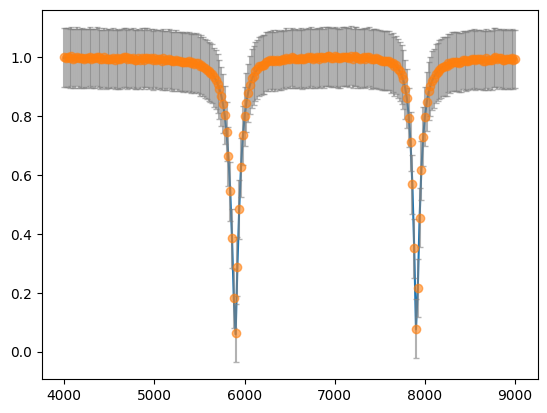

In [28]:
from importlib import reload
import purcell

reload(purcell)

from purcell import fit_purcell

model, red_chi2, params = fit_purcell(frequencies=x[::20], data=noise_data_0[::20], sigmas=data_error_bars[::20])
print(f"Reduced Chi2: {red_chi2:.3f}")
print(f"Ordered parameters: {params}")

In [79]:
dof = len(noise_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(4.256791876444793)

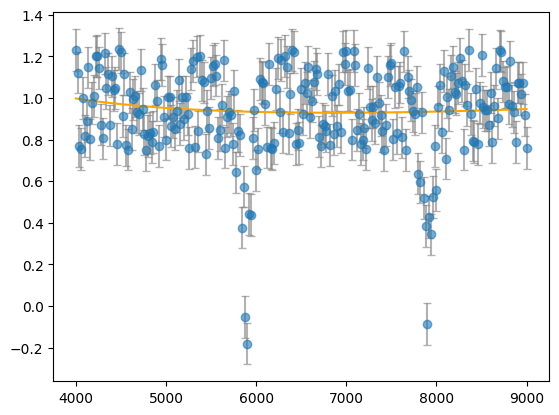

In [93]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(x,*result.x)

plt.errorbar(x[::20],noise_data_0[::20],yerr=data_error_bars[::20], fmt="o", capsize=3, ecolor="gray", alpha=0.6)
plt.plot(x,y_fit, color="orange")

### finding baseline (a.k.a A) guess from data

In [ ]:
baseline_guess = np.average(noise_data_0) # averaging y points to guess the base amplitude
k_guess = 0 # for ideal cases it should be zero
w_0_guess = 0 # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = 3.1e2 # should be given from specsheet
w_p_guess = 6.8e3 # also from specsheet
w_res_0_guess = 7e3 # from specsheet too
J_guess = 1005 # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

In [98]:
result = least_squares(residuals, x0=initial_guess, args=(x, noise_data_0, data_error_bars))
dof = len(noise_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(2.064993747565254)

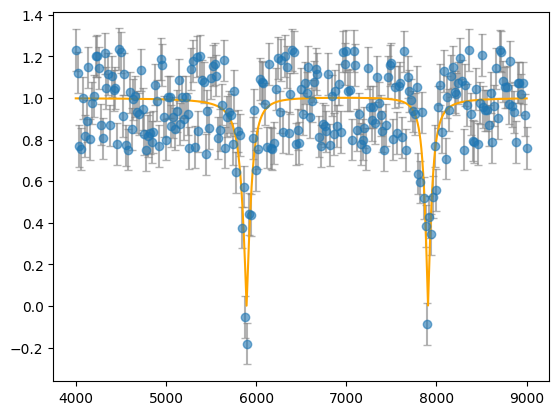

In [99]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(x,*result.x)

plt.errorbar(x[::20],noise_data_0[::20],yerr=data_error_bars[::20], fmt="o", capsize=3, ecolor="gray", alpha=0.6)
plt.plot(x,y_fit, color="orange")

### guessing baseline A, initial tilt k and center dislocation w_0 from linear fit

In [102]:
from scipy.optimize import curve_fit
import numpy as np

def linear_model(x, m, b, c):
    return m * (x + b) + c

params, covariance = curve_fit(linear_model, x, noise_data_0, sigma= data_error_bars,absolute_sigma=True)

m, b, c = params
m_err, b_err, c_err = np.sqrt(np.diag(covariance))

print("m:", m, "+/-", m_err)
print("b:", b, "+/-", b_err)
print("c:", c, "+/-", c_err)

m: -7.3069740681097535e-06 +/- 9.795021137321294e-07
b: -6476.509686351204 +/- 5880657788.148863
c: 0.9428129692625465 +/- 42962.40604178369


In [103]:
baseline_guess = c
k_guess = m # for ideal cases it should be zero
w_0_guess = -b # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = 3.1e2 # should be given from specsheet
w_p_guess = 6.8e3 # also from specsheet
w_res_0_guess = 7e3 # from specsheet too
J_guess = 1005 # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

In [104]:
#fitting previous data from these guesses
result = least_squares(residuals, x0=initial_guess, args=(x, noise_data_0, data_error_bars))
dof = len(noise_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(2.0649937474654556)

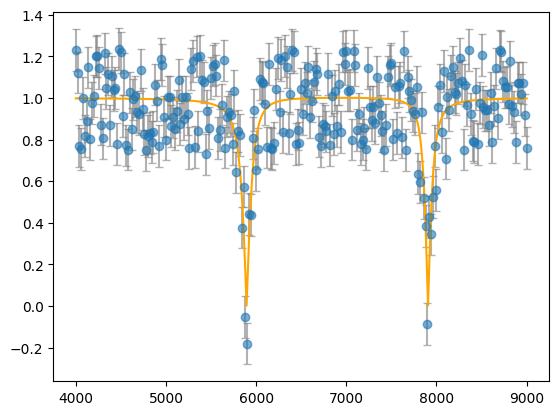

In [105]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(x,*result.x)

plt.errorbar(x[::20],noise_data_0[::20],yerr=data_error_bars[::20], fmt="o", capsize=3, ecolor="gray", alpha=0.6)
plt.plot(x,y_fit, color="orange")

### testing it with tilted data and dislocated centers

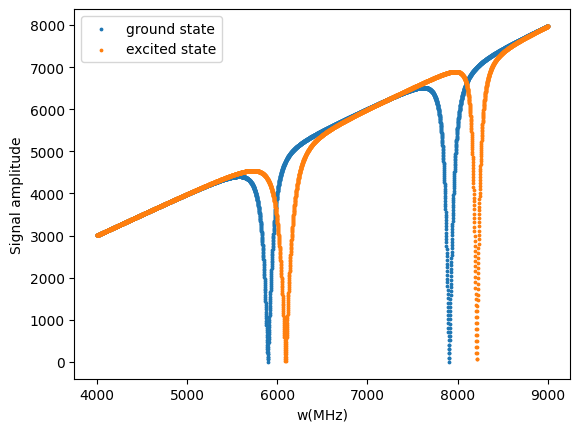

In [2]:
# generating the data
import matplotlib.pyplot as plt
import numpy as np

tilted_test_0,tilted_test_1 = s_out_in(A=10, k=1,w_0=1000, phi=0,k_p=3e2,w_p=6.8e3,w_res_0=7e3,w_res_1=7.5e3,J=1000)

tilted_x = (1e3)*np.linspace(4,9,5001)
tilted_data_0 = tilted_test_0(tilted_x)
tilted_data_1 = tilted_test_1(tilted_x)
plt.scatter(tilted_x,tilted_data_0, s=3, label="ground state")
plt.scatter(tilted_x,tilted_data_1, s=3, label="excited state")
plt.xlabel("w(MHz)")
plt.ylabel("Signal amplitude")
plt.legend()

In [3]:
from numpy.random import random

noise = (random(len(tilted_data_0))-0.5)/2

# adding noise
noise_tilted_data_0 = tilted_data_0 + noise
tilted_data_error_bars = [500]*len(tilted_data_0)

In [4]:
# guessing A,k,w_0
from scipy.optimize import curve_fit
import numpy as np

def linear_model(x, m, b, c):
    return m * (x + b) + c

params, covariance = curve_fit(linear_model, tilted_x, noise_tilted_data_0, sigma=tilted_data_error_bars,absolute_sigma=True)

m, b, c = params
m_err, b_err, c_err = np.sqrt(np.diag(covariance))

print("m:", m, "+/-", m_err)
print("b:", b, "+/-", b_err)
print("c:", c, "+/-", c_err)

m: 0.9222254759902738 +/- 0.00489752480590299
b: -6058.283925029324 +/- 2310970271.854527
c: 4767.057016621469 +/- 2131235566.0841646


In [179]:
# adjusting guesses and fitting
baseline_guess = c
k_guess = m # for ideal cases it should be zero
w_0_guess = -b # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = 3.1e2 # should be given from specsheet
w_p_guess = 6.8e3 # also from specsheet
w_res_0_guess = 7e3 # from specsheet too
J_guess = 1005 # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

#fitting previous data from these guesses
result = least_squares(residuals, x0=initial_guess, args=(tilted_x, noise_tilted_data_0, tilted_data_error_bars))
dof = len(noise_tilted_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(8.260237058525045e-08)

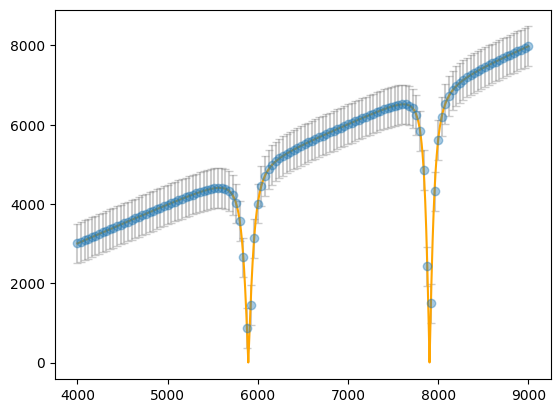

In [180]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(tilted_x,*result.x)

plt.errorbar(tilted_x[::40],noise_tilted_data_0[::40],yerr=tilted_data_error_bars[::40], fmt="o", capsize=3, ecolor="gray", alpha=0.4)
plt.plot(tilted_x,y_fit, color="orange")

### using typical guesses for not provided specsheet parameters

In [27]:
# adjusting guesses and fitting
baseline_guess = c
k_guess = m # for ideal cases it should be zero
w_0_guess = -b # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = 3.1e2 # should be given from specsheet
w_p_guess = 6.9e3 # also from specsheet
w_res_0_guess = 7.1e3 # from specsheet too
J_guess = 1005 # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

#fitting previous data from these guesses
result = least_squares(residuals, x0=initial_guess, args=(tilted_x, noise_tilted_data_0, tilted_data_error_bars))
dof = len(noise_tilted_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

TypeError: residuals() takes 3 positional arguments but 4 were given

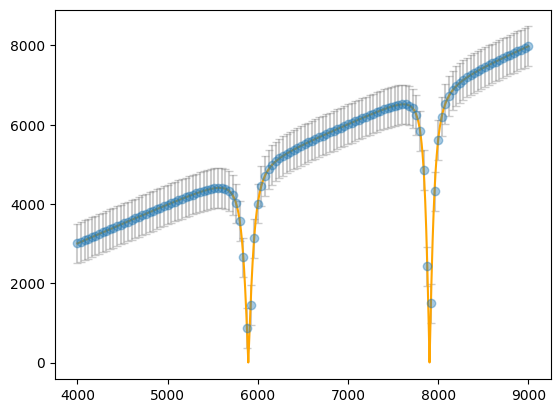

In [230]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(tilted_x,*result.x)

plt.errorbar(tilted_x[::40],noise_tilted_data_0[::40],yerr=tilted_data_error_bars[::40], fmt="o", capsize=3, ecolor="gray", alpha=0.4)
plt.plot(tilted_x,y_fit, color="orange")

### testing in data with nonvanishing phi

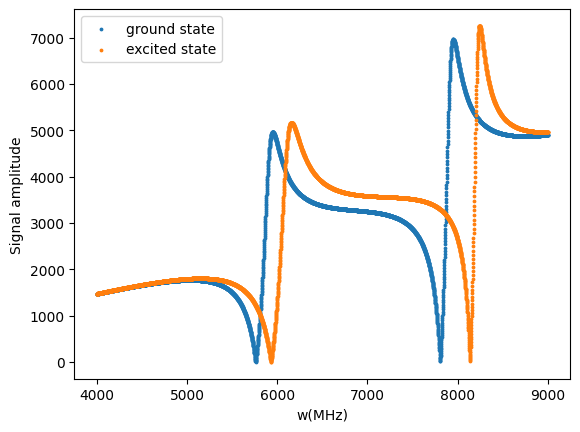

In [231]:
# generating the data
import matplotlib.pyplot as plt
import numpy as np

nvphi_test_0,nvphi_test_1 = s_out_in(A=10, k=1,w_0=1000, phi=1,k_p=3e2,w_p=6.8e3,w_res_0=7e3,w_res_1=7.5e3,J=1000)

nvphi_x = (1e3)*np.linspace(4,9,5001)
nvphi_data_0 = nvphi_test_0(x)
nvphi_data_1 = nvphi_test_1(x)
plt.scatter(nvphi_x,nvphi_data_0, s=3, label="ground state")
plt.scatter(nvphi_x,nvphi_data_1, s=3, label="excited state")
plt.xlabel("w(MHz)")
plt.ylabel("Signal amplitude")
plt.legend()

In [232]:
# adding noise
noise_nvphi_data_0 = nvphi_data_0 + noise
nvphi_data_error_bars = [500]*len(nvphi_data_0)

In [ ]:
# guessing A,k,w_0
from scipy.optimize import curve_fit
import numpy as np

def linear_model(x, m, b, c):
    return m * (x + b) + c

params, covariance = curve_fit(linear_model, nvphi_x, noise_nvphi_data_0, sigma=nvphi_data_error_bars,absolute_sigma=True)

m, b, c = params
m_err, b_err, c_err = np.sqrt(np.diag(covariance))

print("m:", m, "+/-", m_err)
print("b:", b, "+/-", b_err)
print("c:", c, "+/-", c_err)

m: 0.7899819291647698 +/- 0.004899827450395988
b: 41819.13105135312 +/- 1518749939.2720702
c: -35125.74007041982 +/- 1199784963.9089093


In [234]:
# adjusting guesses and fitting
baseline_guess = c
k_guess = m # for ideal cases it should be zero
w_0_guess = -b # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = 3.1e2 # should be given from specsheet
w_p_guess = 6.8e3 # also from specsheet
w_res_0_guess = 7e3 # from specsheet too
J_guess = 1005 # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

#fitting previous data from these guesses
result = least_squares(residuals, x0=initial_guess, args=(nvphi_x, noise_nvphi_data_0, nvphi_data_error_bars))
dof = len(noise_nvphi_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(8.260531411615492e-08)

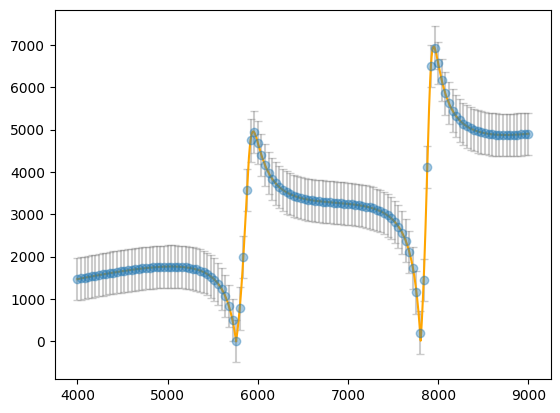

In [235]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(nvphi_x,*result.x)

plt.errorbar(nvphi_x[::40],noise_nvphi_data_0[::40],yerr=nvphi_data_error_bars[::40], fmt="o", capsize=3, ecolor="gray", alpha=0.4)
plt.plot(nvphi_x,y_fit, color="orange")

### ALS for finding and subtracting baseline

In [6]:
from qibocal.protocols.utils import baseline_als

data = tilted_data_0 # change it for other cases
z = baseline_als(data=data,lamda=1e9,p=0.9999)

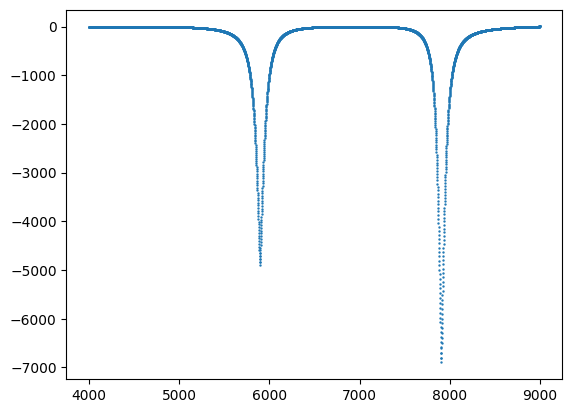

In [7]:
plt.scatter(tilted_x,data-z, s=0.5)

### finding peaks to extract w_l, w_h, k_l, k_h

Peak indices: [1895 3905]
Peak heights: [-4889.37000938 -6898.24411076]
Peak widths at 90% height: [333.80079612 276.87120576]


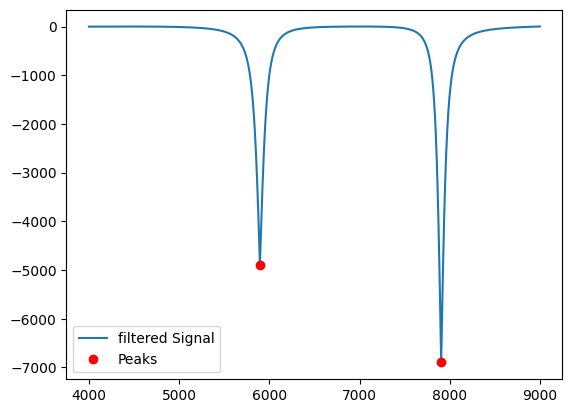

In [8]:
from scipy.signal import find_peaks, peak_widths

peaks, properties = find_peaks(-(data-z),height=0) # height filters peaks above 0
rel_height = 0.9
widths = peak_widths(-(data-z), peaks, rel_height=rel_height)

# Print results
print("Peak indices:", peaks)
print("Peak heights:", -properties["peak_heights"])
print(f"Peak widths at {rel_height*100 :.0f}% height:", widths[0])

# Plot the signal and peaks
plt.plot(tilted_x, data-z, label="filtered Signal")
plt.plot(tilted_x[peaks], (data-z)[peaks], "ro", label="Peaks")
plt.legend()
plt.show()

In [9]:
w_l, w_h = tilted_x[peaks]
k_l, k_h = widths[0]
w_l,w_h,k_l,k_h

(np.float64(5895.0),
 np.float64(7905.0),
 np.float64(333.80079611975407),
 np.float64(276.8712057647708))

### estimating w_r, w_p, k_p and J from analytical solution

equation (2) in https://arxiv.org/pdf/2307.07765

In [10]:
from scipy.optimize import fsolve

def equations(vars):
    w_r, w_p, k_p, J = vars

    expr = np.sqrt((w_r - w_p + 1j * k_p * 0.5)**2 + 4 * (J**2))

    eq1 = 0.5*(w_r + w_p) + 0.5*np.real(expr) - w_h
    eq2 = 0.5*(w_r + w_p) - 0.5*np.real(expr) - w_l
    eq3 = 0.5*k_p - np.imag(expr) - k_h
    eq4 = 0.5*k_p + np.imag(expr) - k_l

    return [eq1, eq2, eq3, eq4]

initial_guess = [1, 1, 1, 1]

solution = fsolve(equations, initial_guess)

w_r_sol, w_p_sol, k_p_sol, J_sol = solution

print("w_r =", w_r_sol)
print("w_p =", w_p_sol)
print("k_p =", k_p_sol)
print("J   =", J_sol)

w_r = 6993.69061972733
w_p = 6806.309380272671
k_p = 610.6720018845249
J   = 1012.102773932494


### wrapping up as the initial guess and fitting the model to the original data

In [17]:
from scipy.optimize import least_squares

def residuals(params, w, y):
    A,k,w_0,phi,k_p,w_p,w_res_0,J = params
    return (A + k*(w-w_0))*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_0)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_0)))) - y

# adjusting guesses and fitting
baseline_guess = c
k_guess = m # for ideal cases it should be zero
w_0_guess = -b # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = k_p_sol # should be given from specsheet
w_p_guess = w_p_sol # also from specsheet
w_res_0_guess = w_r_sol # from specsheet too
J_guess = J_sol # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

#fitting previous data from these guesses
result = least_squares(residuals, x0=initial_guess, args=(tilted_x, tilted_data_0))
dof = len(noise_tilted_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2, *result.x

(np.float64(2.0134188776850737e-26),
 np.float64(4895.48355999278),
 np.float64(1.0),
 np.float64(5885.48355999278),
 np.float64(-2.4857846118536692e-17),
 np.float64(300.0),
 np.float64(6800.0),
 np.float64(7000.0),
 np.float64(1000.0))

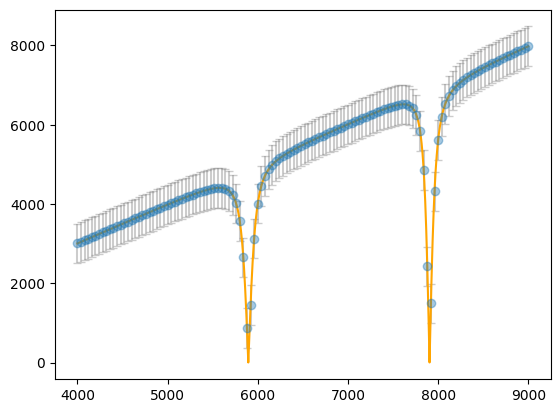

In [16]:
import matplotlib.pyplot as plt

# the fitting curve
def s_out_in_for_fitting_0(w,A,k,w_0,phi,k_p,w_p,w_res_0,J):
    return (A + k*(w-w_0))*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_0)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_0))))

y_fit = s_out_in_for_fitting_0(tilted_x,*result.x)

plt.errorbar(tilted_x[::40],noise_tilted_data_0[::40],yerr=tilted_data_error_bars[::40], fmt="o", capsize=3, ecolor="gray", alpha=0.4)
plt.plot(tilted_x,y_fit, color="orange")

# Test cases for the final fit

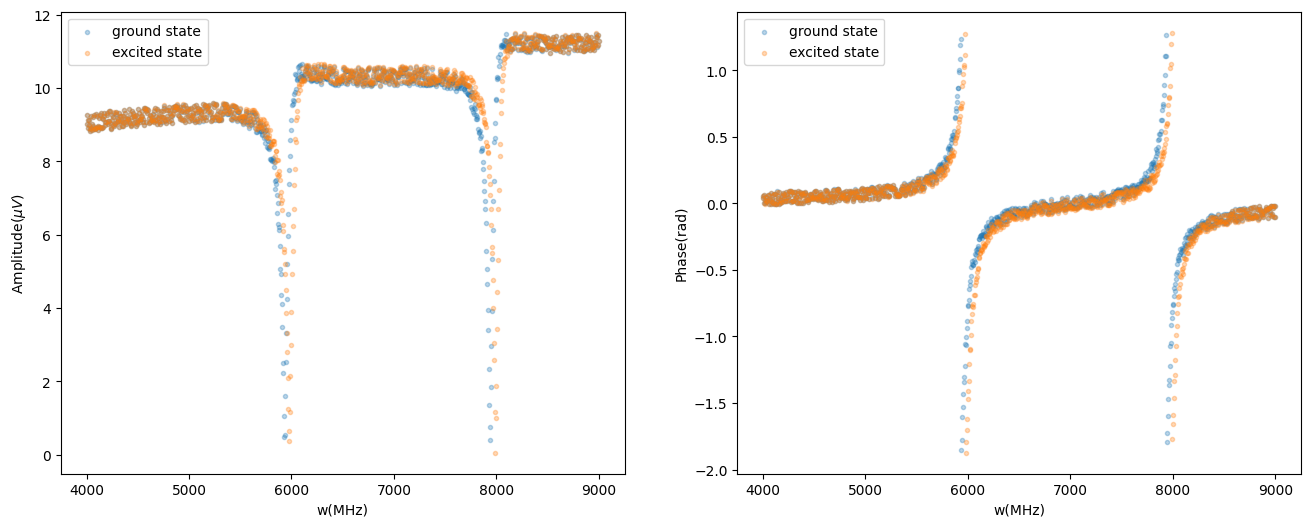

In [37]:
# generating the data
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import random

from importlib import reload
import purcell

reload(purcell)

from purcell import s_out_in

# range of frequencies
x = (1e3)*np.linspace(4,9,1001)

# convention for parameters ordering: A,k,w_0,phi,k_p,w_p,w_r,J
params_0 = [10,2,5000,0.3,2e2,6.9e3,7e3,1000] # for ground state 0
params_1 = [10,2,5000,0.3,2e2,6.9e3,7.1e3,1000] # for excited state 1

data_0 = s_out_in(x, *params_0)
data_1 = s_out_in(x, *params_1)

# adding noise and error bars
amp_noise = (random(len(data_0))-0.5)/2
phase_noise = (random(len(data_0))-0.5)/10

# Create figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left subplot: absolute amplitude
axes[0].scatter(x,abs(data_0) + amp_noise, label="ground state", marker=".", alpha=0.3)
axes[0].scatter(x,abs(data_1) + amp_noise, label="excited state", marker=".", alpha=0.3)
axes[0].set_ylabel(r"Amplitude($\mu V$)")
axes[0].set_xlabel("w(MHz)")
axes[0].legend()

# Right subplot: phase
axes[1].scatter(x,np.angle(data_0) + phase_noise, label="ground state",marker=".", alpha=0.3)
axes[1].scatter(x,np.angle(data_1) + phase_noise, label="excited state",marker=".", alpha=0.3)
axes[1].set_ylabel("Phase(rad)")
axes[1].set_xlabel("w(MHz)")
axes[1].legend()

Peak indices: [386 787]
Peak heights: [ -9.97601364 -10.91740663]
Peak widths at 90% height: [67.71073821 69.33130551]
Parameters ordering: A,k,w_0,phi,k_p,w_p,w_r,J
Fitted parameters: [3.70058412e+03 3.69262765e+03 9.14916100e+06 2.96148249e-01
 1.99015315e+02 6.90510235e+03 6.99447747e+03 1.00029914e+03]
Normalized differences from ideal parameters: [3.69058412e+02 1.84531383e+03 1.82883220e+03 1.28391692e-02
 4.92342376e-03 7.39470308e-04 7.88932853e-04 2.99142234e-04]
Covariance matrix diagonal: [3.46228181e+11 3.46228177e+11 2.12547171e+18 9.43096917e-06
 9.64424826e-01 2.14028640e+01 2.15991666e+01 8.28217627e-02]


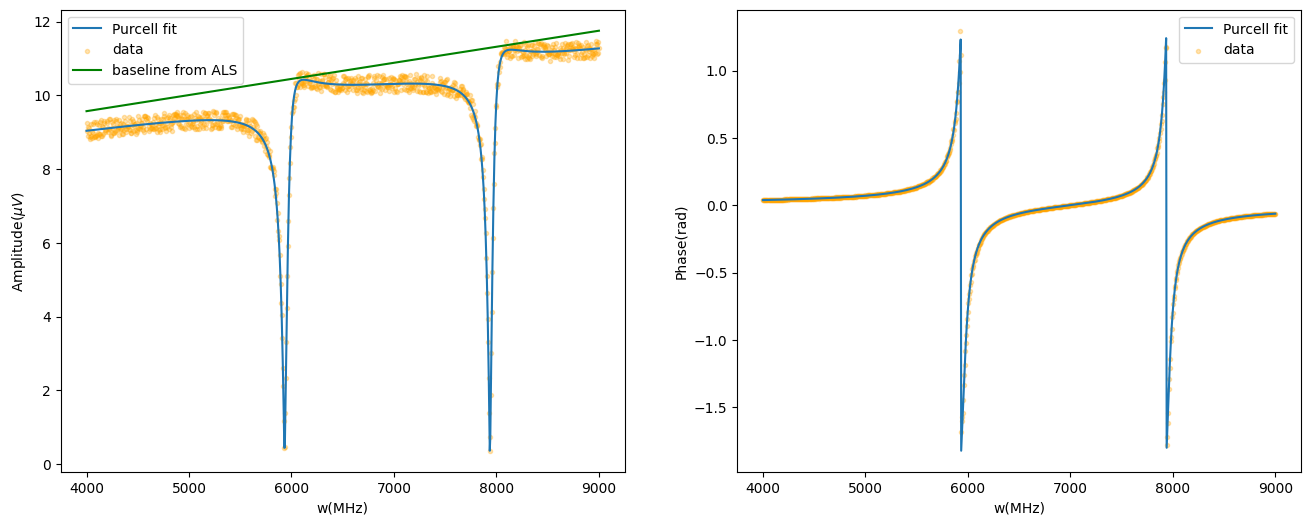

In [38]:
from importlib import reload
import purcell

reload(purcell)

from purcell import fit_purcell

cov, params = fit_purcell(frequencies=x, data=data_0+amp_noise)
print("Parameters ordering: A,k,w_0,phi,k_p,w_p,w_r,J")
print(f"Fitted parameters: {params}")
print(f"Normalized differences from ideal parameters: {abs(params-params_0)/params_0}")
print(f"Covariance matrix diagonal: {np.diag(cov)}")
